## Results

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("data")
FIG_DIR  = Path("figures_results")
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

REQUIRED = [
    "temperature", "similarity",
    "language", "license", "qualified_name", "n_lines",
    "sample_idx", "original_suffix", "generated_suffix"
]

def parse_model_lang_from_filename(fp: Path) -> tuple[str, str]:
    stem = fp.stem
    parts = stem.split("_dolos_results_")
    if len(parts) != 2:
        raise ValueError(f"Unexpected filename format: {fp.name}")
    model = parts[0].lower().strip()
    lang  = parts[1].lower().strip()
    return model, lang


MODEL_LABELS = {
    "qwen": "qwen",
    "deepseek": "deepseek",
    "gemini": "gemini_flash_lite",
    "gpt4": "gpt4o_mini_2024_07_18",
}

def load_all_results(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("*_dolos_results_*.csv"))
    if not files:
        raise FileNotFoundError(f"No *_dolos_results_*.csv files found in: {data_dir.resolve()}")

    frames = []
    for fp in files:
        d = pd.read_csv(fp)

        missing = [c for c in REQUIRED if c not in d.columns]
        if missing:
            raise ValueError(f"{fp.name} missing columns {missing}. Found: {list(d.columns)}")

        model_from_fn, lang_from_fn = parse_model_lang_from_filename(fp)
        model_label = MODEL_LABELS.get(model_from_fn, model_from_fn)

        out = d.copy()

     
        out["model_label"] = model_label

   

        out["temperature"] = pd.to_numeric(out["temperature"], errors="coerce")
        out["similarity"]  = pd.to_numeric(out["similarity"], errors="coerce")
        out = out.dropna(subset=["temperature", "similarity"])

        frames.append(out)

    df = pd.concat(frames, ignore_index=True)

    # remove old artefact if it exists
    df = df[df["model_label"] != "MODEL_1"].copy()

    df["temperature"] = df["temperature"].round(3)
    return df

df = load_all_results(DATA_DIR)

print("Loaded rows:", len(df))
print("Models:", sorted(df["model_label"].unique()))
print("Languages:", sorted(df["language"].unique()))
print("Temperatures:", sorted(df["temperature"].unique()))

lang_order = df.groupby("language")["similarity"].mean().sort_values(ascending=False).index.tolist()
temp_order = sorted(df["temperature"].unique())


Loaded rows: 13202
Models: ['deepseek', 'gemini_flash_lite', 'gpt4o_mini_2024_07_18', 'qwen']
Languages: ['c', 'go', 'haskell', 'java', 'javascript', 'julia', 'perl', 'python', 'ruby', 'rust', 'scala']
Temperatures: [np.float64(0.2), np.float64(0.4), np.float64(0.8)]


,model_label,temperature,mean_similarity,median_similarity,max_similarity,n_samples,share_ge_08
0,deepseek,0.2,0.2099,0.1407,1.0,1101,2.7248
1,deepseek,0.4,0.2058,0.1364,1.0,1101,2.5431
2,deepseek,0.8,0.2072,0.1328,1.0,1101,3.1789
3,gemini_flash_lite,0.2,0.1646,0.1002,1.0,1103,1.9946
4,gemini_flash_lite,0.4,0.1658,0.0913,1.0,1103,2.4479
5,gemini_flash_lite,0.8,0.1596,0.0861,1.0,1102,2.0871
6,gpt4o_mini_2024_07_18,0.2,0.1362,0.0667,1.0,1099,1.3649
7,gpt4o_mini_2024_07_18,0.4,0.1384,0.0718,1.0,1099,1.5469
8,gpt4o_mini_2024_07_18,0.8,0.1351,0.0681,1.0,1099,1.6379
9,qwen,0.2,0.1429,0.0732,1.0,1098,1.9126


,language,temperature,mean_similarity,median_similarity,max_similarity,n_samples,share_ge_08
0,c,0.2,0.1267,0.0730,0.8092,400,0.2500
1,c,0.4,0.1298,0.0721,0.8488,400,0.2500
2,c,0.8,0.1251,0.0744,0.8488,400,0.5000
3,go,0.2,0.2234,0.1653,1.0000,400,4.2500
4,go,0.4,0.2283,0.1579,1.0000,400,5.2500
5,go,0.8,0.2257,0.1598,1.0000,400,5.7500
6,haskell,0.2,0.1166,0.0653,0.8067,400,0.2500
7,haskell,0.4,0.1138,0.0638,0.8203,400,0.2500
8,haskell,0.8,0.1119,0.0624,0.8175,400,0.5000
9,java,0.2,0.2145,0.1482,1.0000,400,2.2500


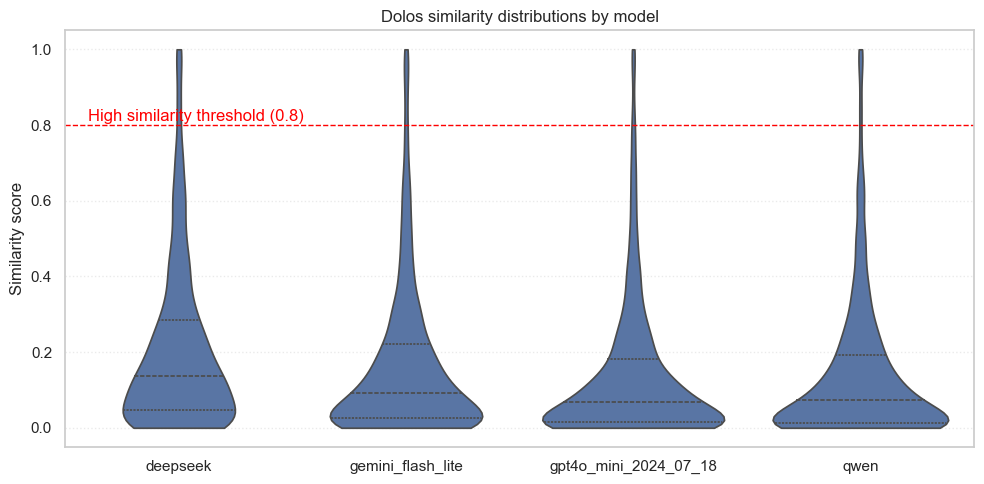

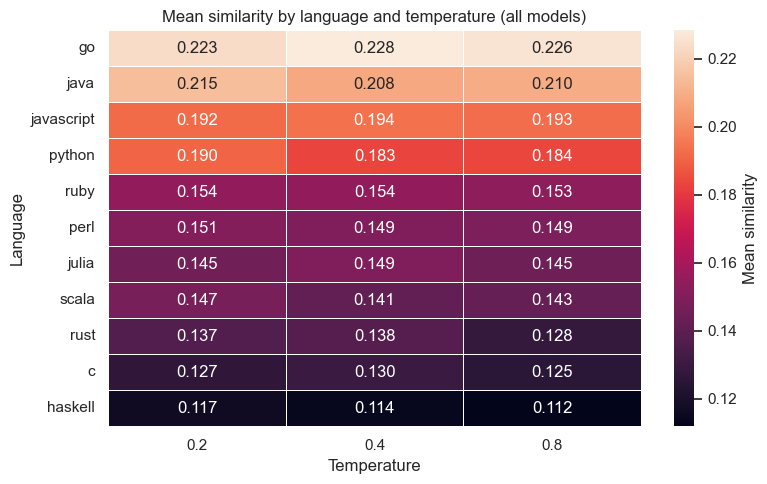

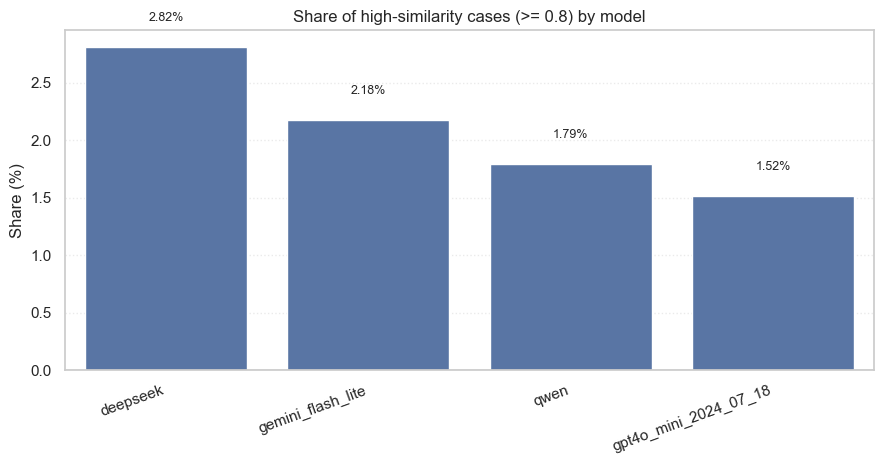

Saved figures + tables to: C:\Users\Feresh\Documents\EPRP_Final\figures_results


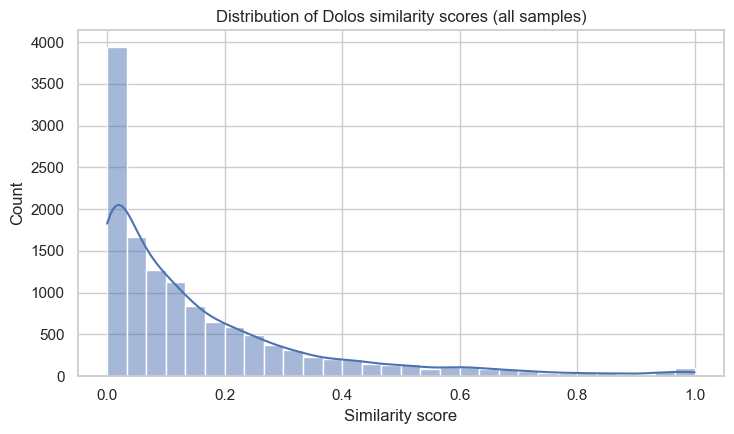

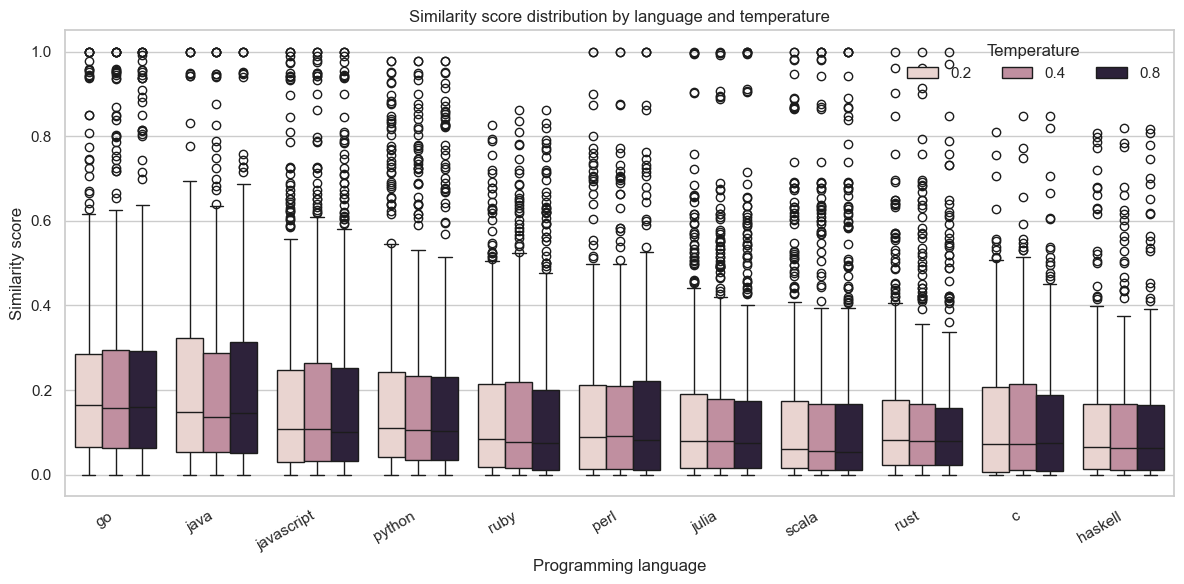

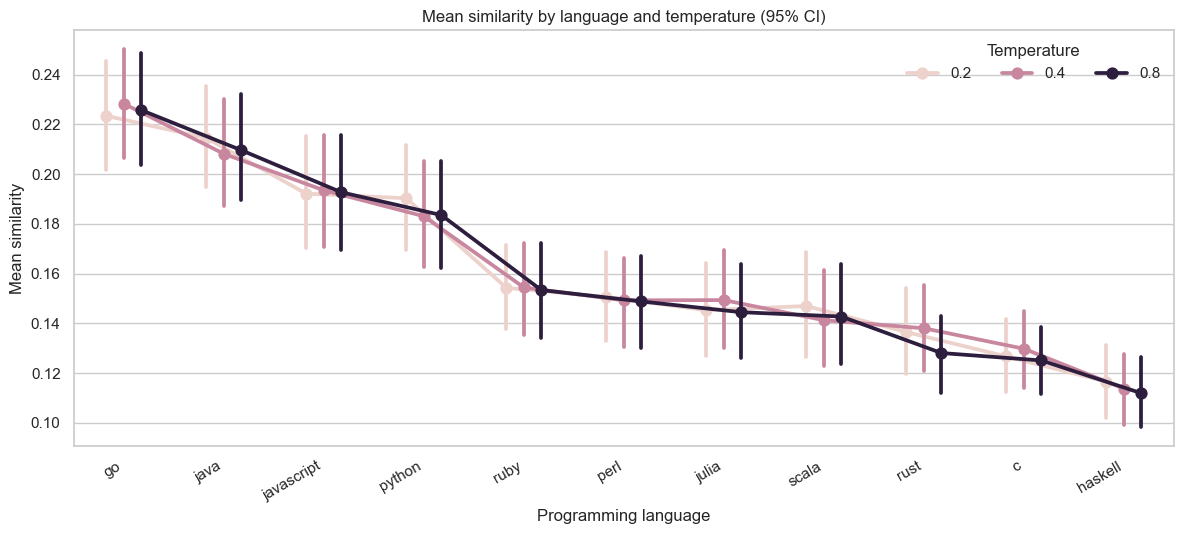

Saved to: C:\Users\Feresh\Documents\EPRP_Final\figures_results


In [ ]:
# ----------------------------
# 2) Summary tables (model x temperature) + (language x temperature)
# ----------------------------
THRESHOLD = 0.8

model_temp_summary = (
    df.groupby(["model_label", "temperature"])
      .agg(
          mean_similarity=("similarity", "mean"),
          median_similarity=("similarity", "median"),
          max_similarity=("similarity", "max"),
          n_samples=("similarity", "size"),
          share_ge_08=("similarity", lambda x: (x >= THRESHOLD).mean() * 100),
      )
      .reset_index()
      .sort_values(["model_label", "temperature"])
)

language_temp_summary = (
    df.groupby(["language", "temperature"])
      .agg(
          mean_similarity=("similarity", "mean"),
          median_similarity=("similarity", "median"),
          max_similarity=("similarity", "max"),
          n_samples=("similarity", "size"),
          share_ge_08=("similarity", lambda x: (x >= THRESHOLD).mean() * 100),
      )
      .reset_index()
      .sort_values(["language", "temperature"])
)

model_temp_summary.to_csv(FIG_DIR / "table_model_temperature_summary.csv", index=False)
language_temp_summary.to_csv(FIG_DIR / "table_language_temperature_summary.csv", index=False)

display(model_temp_summary.round(4))
display(language_temp_summary.round(4))


# ----------------------------
# 3) Plot A: Violin — similarity distributions by model
# ----------------------------
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="model_label",
    y="similarity",
    inner="quartile",
    cut=0
)
plt.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1)
plt.text(-0.4, THRESHOLD + 0.01, f"High similarity threshold ({THRESHOLD})", color="red")
plt.title("Dolos similarity distributions by model")
plt.ylabel("Similarity score")
plt.xlabel("")
plt.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "A_violin_similarity_by_model.png", dpi=300)
plt.show()


# ----------------------------
# 4) Plot B: Heatmap — mean similarity by language x temperature (all models combined)
# ----------------------------
heat_lang = (
    df.groupby(["language", "temperature"])["similarity"]
      .mean()
      .reset_index()
      .pivot(index="language", columns="temperature", values="similarity")
      .reindex(lang_order)
)

plt.figure(figsize=(8, max(5, 0.35 * len(heat_lang))))
sns.heatmap(
    heat_lang,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Mean similarity"}
)
plt.title("Mean similarity by language and temperature (all models)")
plt.ylabel("Language")
plt.xlabel("Temperature")
plt.tight_layout()
plt.savefig(FIG_DIR / "C_heatmap_mean_similarity_language_temperature.png", dpi=300)
plt.show()


# ----------------------------
# 5) Plot C: High-similarity rate >= 0.8 by model (bar)
# ----------------------------
high_rate = (
    df.groupby("model_label")["similarity"]
      .apply(lambda s: (s >= THRESHOLD).mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 4.8))
ax = sns.barplot(x=high_rate.index, y=high_rate.values)
plt.axhline(0, color="black", linewidth=0.8)
plt.title(f"Share of high-similarity cases (>= {THRESHOLD}) by model")
plt.ylabel("Share (%)")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle=":", alpha=0.4)

# value labels
for i, v in enumerate(high_rate.values):
    ax.text(i, v + 0.2, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "D_bar_high_similarity_share_by_model.png", dpi=300)
plt.show()


print("Saved figures + tables to:", FIG_DIR.resolve())


# ----------------------------
# 6) Plot D: Overall distribution (hist + KDE)
# ----------------------------
plt.figure(figsize=(7.5, 4.5))
sns.histplot(df["similarity"], bins=30, kde=True)
plt.title("Distribution of Dolos similarity scores (all samples)")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "A_similarity_distribution_overall.png", dpi=300)
plt.show()

# ----------------------------
# 7) Plot E: Boxplot by language with temperature hue 
# ----------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="language",
    y="similarity",
    hue="temperature",
    order=lang_order,
    hue_order=temp_order
)
plt.title("Similarity score distribution by language and temperature")
plt.xlabel("Programming language")
plt.ylabel("Similarity score")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Temperature", frameon=False, ncol=len(temp_order))
plt.tight_layout()
plt.savefig(FIG_DIR / "B_boxplot_similarity_language_temperature.png", dpi=300)
plt.show()

# ----------------------------
# 8) Plot F: Mean similarity by language x temperature (pointplot + CI) (YOUR STYLE)
# ----------------------------
plt.figure(figsize=(12, 5.5))
sns.pointplot(
    data=df,
    x="language",
    y="similarity",
    hue="temperature",
    order=lang_order,
    hue_order=temp_order,
    estimator=np.mean,
    errorbar=("ci", 95),
    dodge=0.35,
    markers="o",
    linestyles="-"
)
plt.title("Mean similarity by language and temperature (95% CI)")
plt.xlabel("Programming language")
plt.ylabel("Mean similarity")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Temperature", frameon=False, ncol=len(temp_order))
plt.tight_layout()
plt.savefig(FIG_DIR / "C_mean_similarity_language_temperature_pointplot.png", dpi=300)
plt.show()

print("Saved to:", FIG_DIR.resolve())



In [59]:
import pandas as pd

THRESHOLD = 0.8

high_sim_table = (
    df.assign(high_similarity = df["similarity"] >= THRESHOLD)
      .groupby("language")
      .agg(
          total_samples = ("similarity", "count"),
          high_similarity_count = ("high_similarity", "sum"),
          high_similarity_share = ("high_similarity", "mean"),
          max_similarity = ("similarity", "max")
      )
      .reset_index()
)

# Convert share to percentage
high_sim_table["high_similarity_share_pct"] = 100 * high_sim_table["high_similarity_share"]

# Sort by risk: highest share first, then absolute count
high_sim_table = high_sim_table.sort_values(
    ["high_similarity_share_pct", "high_similarity_count"],
    ascending=False
)

# Keep only useful columns for the report
high_sim_table = high_sim_table[
    [
        "language",
        "total_samples",
        "high_similarity_count",
        "high_similarity_share_pct",
        "max_similarity",
    ]
]

# Round nicely
high_sim_table["high_similarity_share_pct"] = high_sim_table["high_similarity_share_pct"].round(2)
high_sim_table["max_similarity"] = high_sim_table["max_similarity"].round(3)

# Save for report
high_sim_table.to_csv("results_high_similarity_over_0_8_by_language.csv", index=False)

display(high_sim_table)
print("Saved: results_high_similarity_over_0_8_by_language.csv")


,language,total_samples,high_similarity_count,high_similarity_share_pct,max_similarity
1,go,1200,61,5.08,1.000
7,python,1200,48,4.00,0.978
4,javascript,1200,43,3.58,1.000
10,scala,1199,32,2.67,1.000
3,java,1200,28,2.33,1.000
5,julia,1200,22,1.83,1.000
6,perl,1200,14,1.17,1.000
9,rust,1200,11,0.92,1.000
8,ruby,1203,7,0.58,0.863
0,c,1200,4,0.33,0.849


Saved: results_high_similarity_over_0_8_by_language.csv


In [60]:
from IPython.display import display

THRESHOLD = 0.8

high = df[df["similarity"] >= THRESHOLD].copy()

# one sample per language: take the max similarity row
one_per_lang = (
    high.sort_values(["language", "similarity", "temperature"], ascending=[True, False, True])
        .groupby("language", as_index=False)
        .head(1)
        .reset_index(drop=True)
)

one_per_lang["case_id"] = [f"{lang.upper()}_HS" for lang in one_per_lang["language"]]

print("Languages with ≥0.8 case:", one_per_lang["language"].nunique())
display(one_per_lang[[
    "case_id","language","model","temperature","similarity","license","qualified_name","n_lines","sample_idx"
]].sort_values("similarity", ascending=False))




Languages with ≥0.8 case: 11


,case_id,language,model,temperature,similarity,license,qualified_name,n_lines,sample_idx
1,GO_HS,go,deepseek,0.2,1.000000,GPL-3.0,antlr::sequence::sequence_base_listener.go,136,0
4,JAVASCRIPT_HS,javascript,gpt4o_mini_2024_07_18,0.2,1.000000,AGPL-3.0,Documentation::html::classtest_app.js,99,0
3,JAVA_HS,java,deepseek,0.2,1.000000,AGPL-3.0,src::main::java::minhhai2209::jirapluginconver...,69,0
10,SCALA_HS,scala,deepseek,0.2,1.000000,GPL-3.0,src::macos::keycodes.rs,56,0
9,RUST_HS,rust,deepseek,0.2,1.000000,GPL-3.0,curses_defs.go,53,0
5,JULIA_HS,julia,deepseek,0.8,1.000000,GPL-3.0,src::Clustering.jl,72,0
6,PERL_HS,perl,deepseek,0.2,1.000000,GPL-3.0,lib::Canto::ChadoDB::Chadoprop.pm,102,0
7,PYTHON_HS,python,deepseek,0.2,0.977813,AGPL-3.0,App::run,248,0
8,RUBY_HS,ruby,gpt4o_mini_2024_07_18,0.8,0.862745,GPL-3.0,attributes::default.rb,65,0
0,C_HS,c,gpt4o_mini_2024_07_18,0.4,0.848837,AGPL-3.0,aws-cpp-sdk-codecommit::include::aws::codecomm...,138,0


In [61]:
from IPython.display import HTML, display
import html
import pandas as pd

def show_row_side_by_side(row, max_chars=20000):
    gen = str(row["generated_suffix"])[:max_chars] if pd.notna(row["generated_suffix"]) else ""
    ref = str(row["original_suffix"])[:max_chars] if pd.notna(row["original_suffix"]) else ""

    header = f"""
    <div style="font-family:system-ui; margin:14px 0 8px 0;">
      <div style="font-size:18px; font-weight:800;">
        {html.escape(str(row['case_id']))} — {html.escape(str(row['language']))}
        — {html.escape(str(row['model']))} — T={row['temperature']} — similarity={row['similarity']:.3f}
      </div>
      <div style="margin-top:4px; color:#444;">
        <b>qualified_name:</b> {html.escape(str(row['qualified_name']))}
        &nbsp; | &nbsp; <b>license:</b> {html.escape(str(row['license']))}
        &nbsp; | &nbsp; <b>sample_idx:</b> {row['sample_idx']}
      </div>
    </div>
    """

    def box(title, text):
        return f"""
        <div style="flex:1; min-width:420px;">
          <div style="font-weight:700; margin-bottom:6px;">{title}</div>
          <pre style="white-space:pre; overflow:auto; max-height:520px; padding:12px;
                      border:1px solid #ddd; border-radius:12px; background:#fafafa; font-size:12px;">
{html.escape(text)}
          </pre>
        </div>
        """

    body = f"""
    {header}
    <div style="display:flex; gap:12px; align-items:flex-start; flex-wrap:wrap;">
      {box("Generated suffix (model output)", gen)}
      {box("Original suffix (withheld reference)", ref)}
    </div>
    <hr style="margin:16px 0;"/>
    """
    display(HTML(body))

# show all (one per language)
for _, r in one_per_lang.sort_values("language").iterrows():
    show_row_side_by_side(r)


## Group by model

In [62]:
model_temp_summary = (
    df.groupby(["model", "temperature"])
      .agg(
          mean_similarity=("similarity", "mean"),
          median_similarity=("similarity", "median"),
          max_similarity=("similarity", "max"),
          n_samples=("similarity", "size"),
          share_ge_08=("similarity", lambda x: (x >= 0.8).mean())
      )
      .reset_index()
)

# percentages
model_temp_summary["share_ge_08"] *= 100

display(
    model_temp_summary.sort_values(
        ["model", "temperature"]
    ).round(4)
)


,model,temperature,mean_similarity,median_similarity,max_similarity,n_samples,share_ge_08
0,deepseek,0.2,0.2099,0.1407,1.0,1101,2.7248
1,deepseek,0.4,0.2058,0.1364,1.0,1101,2.5431
2,deepseek,0.8,0.2072,0.1328,1.0,1101,3.1789
3,gemini_flash_lite,0.2,0.1646,0.1002,1.0,1103,1.9946
4,gemini_flash_lite,0.4,0.1658,0.0913,1.0,1103,2.4479
5,gemini_flash_lite,0.8,0.1596,0.0861,1.0,1102,2.0871
6,gpt4o_mini_2024_07_18,0.2,0.1362,0.0667,1.0,1099,1.3649
7,gpt4o_mini_2024_07_18,0.4,0.1384,0.0718,1.0,1099,1.5469
8,gpt4o_mini_2024_07_18,0.8,0.1351,0.0681,1.0,1099,1.6379
9,qwen,0.2,0.1429,0.0732,1.0,1098,1.9126


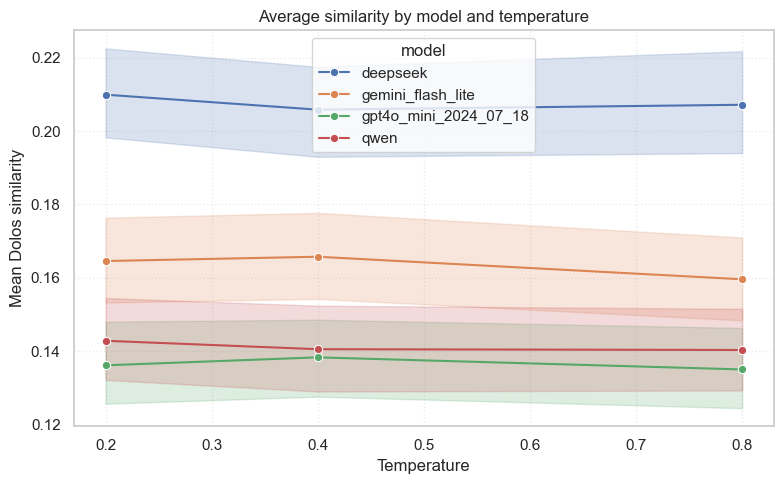

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df[df["model"] != "MODEL_1"].copy()

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df,
    x="temperature",
    y="similarity",
    hue="model",
    estimator="mean",
    errorbar="ci",
    marker="o"
)

plt.title("Average similarity by model and temperature")
plt.ylabel("Mean Dolos similarity")
plt.xlabel("Temperature")
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


In [64]:
THRESHOLD = 0.8

model_risk = (
    df.groupby("model")
      .agg(
          n_samples=("similarity", "size"),
          n_high=("similarity", lambda x: (x >= THRESHOLD).sum()),
          share_high=("similarity", lambda x: (x >= THRESHOLD).mean())
      )
      .reset_index()
)

model_risk["share_high"] *= 100

display(
    model_risk.sort_values("share_high", ascending=False)
               .round(3)
)


,model,n_samples,n_high,share_high
0,deepseek,3303,93,2.816
1,gemini_flash_lite,3308,72,2.177
3,qwen,3294,59,1.791
2,gpt4o_mini_2024_07_18,3297,50,1.517
